<a href="https://colab.research.google.com/github/purvatawade/Smart-Inventory-Sales-Optimizer/blob/main/retail_analytics_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset and clean the column headers systematically
df = pd.read_csv('superstore.csv', encoding='utf-8')
df.columns = df.columns.str.replace(' ', '_').str.replace('-', '_').str.lower()

# Convert date components into clean datetime formats
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])

print("=== CORE ENVIRONMENT INITIALIZED COMPLETED ===")
print(f"Total Database Rows Loaded: {df.shape[0]} records.")

=== CORE ENVIRONMENT INITIALIZED COMPLETED ===
Total Database Rows Loaded: 10800 records.


--- Average Delivery Delays by Shipping Mode ---
ship_mode
First Class       2.18
Same Day          0.04
Second Class      3.24
Standard Class    5.01


--- Performance Matrix Across Core Business Segments ---
                 order_volume  total_sales  total_profit  profit_margin_pct
category                                                                   
Furniture              8028.0    741999.80      18451.27               2.49
Office Supplies       22906.0    719047.03     122490.80              17.04
Technology             6939.0    836154.03     145454.95              17.40




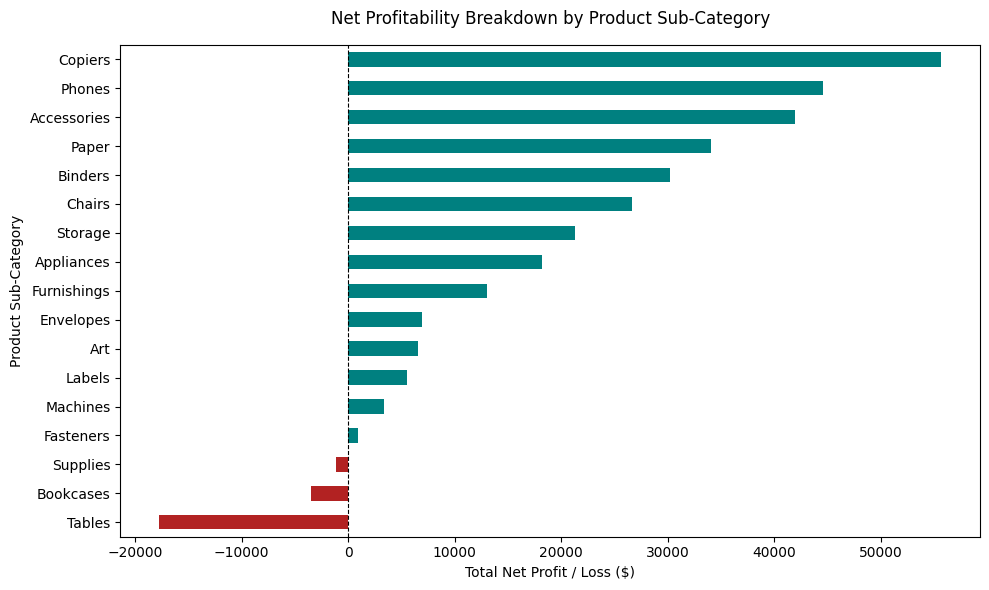

In [2]:
# Calculate shipping gap metrics
df['shipping_gap_days'] = (df['ship_date'] - df['order_date']).dt.days

print("--- Average Delivery Delays by Shipping Mode ---")
print(df.groupby('ship_mode')['shipping_gap_days'].mean().round(2).to_string())
print("\n" + "="*60 + "\n")

print("--- Performance Matrix Across Core Business Segments ---")
category_perf = df.groupby('category').agg(
    order_volume=('quantity', 'sum'),
    total_sales=('sales', 'sum'),
    total_profit=('profit', 'sum')
).round(2)
category_perf['profit_margin_pct'] = ((category_perf['total_profit'] / category_perf['total_sales']) * 100).round(2)
print(category_perf)
print("\n" + "="*60 + "\n")

# Render Horizontal Profit/Loss Breakdown Layout
sub_cat_profit = df.groupby('sub_category')['profit'].sum().sort_values()
plt.figure(figsize=(10, 6))
sub_cat_profit.plot(kind='barh', color=['firebrick' if x < 0 else 'teal' for x in sub_cat_profit])
plt.title('Net Profitability Breakdown by Product Sub-Category', fontsize=12, pad=15)
plt.xlabel('Total Net Profit / Loss ($)', fontsize=10)
plt.ylabel('Product Sub-Category', fontsize=10)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

=== MACHINE LEARNING FORECAST PERFORMANCE METRICS ===
Mean Absolute Error (MAE): 4.43 units
Root Mean Squared Error (RMSE): 5.88 units



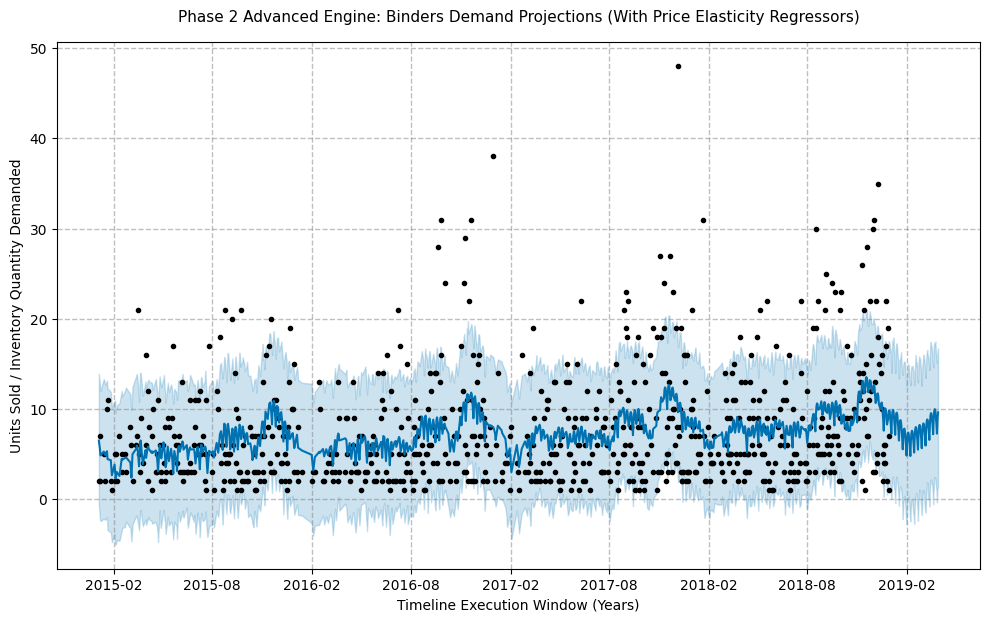

In [3]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Isolate top high-volume sub-category targets
model_data = df[df['sub_category'] == 'Binders'].copy()

# Generate multi-variable covariate framework
prophet_df = model_data.groupby('order_date').agg(
    y=('quantity', 'sum'),
    discount_rate=('discount', 'mean')
).reset_index()
prophet_df.rename(columns={'order_date': 'ds'}, inplace=True)

# Train hyperparameter-tuned advanced model
advanced_model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False, changepoint_prior_scale=0.05)
advanced_model.add_regressor('discount_rate')
advanced_model.fit(prophet_df)

# Construct 90-day future matrix populated with baseline markdown averages
future_timeline = advanced_model.make_future_dataframe(periods=90, freq='D')
historical_avg_discount = prophet_df['discount_rate'].mean()
future_timeline = future_timeline.merge(prophet_df[['ds', 'discount_rate']], on='ds', how='left')
future_timeline['discount_rate'] = future_timeline['discount_rate'].fillna(historical_avg_discount)

# Calculate dynamic predictions
advanced_forecast = advanced_model.predict(future_timeline)

# Model Validation Layer
evaluation_df = advanced_forecast.merge(prophet_df[['ds', 'y']], on='ds', how='inner')
mae = mean_absolute_error(evaluation_df['y'], evaluation_df['yhat'])
rmse = np.sqrt(mean_squared_error(evaluation_df['y'], evaluation_df['yhat']))

print("=== MACHINE LEARNING FORECAST PERFORMANCE METRICS ===")
print(f"Mean Absolute Error (MAE): {mae:.2f} units")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} units\n")

# Render updated prediction trend charts
fig_forecast = advanced_model.plot(advanced_forecast)
plt.title("Phase 2 Advanced Engine: Binders Demand Projections (With Price Elasticity Regressors)", fontsize=11, pad=15)
plt.xlabel("Timeline Execution Window (Years)", fontsize=10)
plt.ylabel("Units Sold / Inventory Quantity Demanded", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [6]:
import warnings
warnings.filterwarnings('ignore')
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules

# Strip out empty rows or float exceptions before compilation
df_clean = df.dropna(subset=['sub_category']).copy()
df_clean['sub_category'] = df_clean['sub_category'].astype(str)

# Aggregate vertical order rows into unified horizontal shopping bag arrays
baskets = df_clean.groupby('order_id')['sub_category'].apply(list).reset_index()
basket_list = baskets['sub_category'].tolist()

# Apply binary transaction mask configuration matrices
te = TransactionEncoder()
te_ary = te.fit(basket_list).transform(basket_list)
basket_df = pd.DataFrame(te_ary, columns=te.columns_)

# Execute optimized pattern tree graph mining loops
frequent_itemsets = fpgrowth(basket_df, min_support=0.01, use_colnames=True)
all_rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

# Isolate high-confidence behavioral patterns
conditional_rules = all_rules[all_rules['confidence'] >= 0.15].copy()
conditional_rules = conditional_rules.sort_values(by="lift", ascending=False)

print(f"=== REVENUE RECOMMENDATION ENGINE CORES LOCKED ===")
print(f"Scanned Carts: {len(basket_list)} | Discovered Affinity Rules: {len(conditional_rules)}\n")

# Clean bracket representations for final printed table display
conditional_rules['antecedents'] = conditional_rules['antecedents'].apply(lambda x: list(x))
conditional_rules['consequents'] = conditional_rules['consequents'].apply(lambda x: list(x))
print(conditional_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10).to_string())

# --- AUTOMATED WORKSPACE SHEET EXPORTS ---
advanced_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_csv('prophet_inventory_forecast.csv', index=False)
conditional_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].to_csv('market_basket_rules.csv', index=False)
print("\n=== SYSTEM SUCCESS: spreadsheets generated and ready for local dashboard design downloads! ===")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

=== REVENUE RECOMMENDATION ENGINE CORES LOCKED ===
Scanned Carts: 5009 | Discovered Affinity Rules: 24

           antecedents consequents   support  confidence      lift
28    [Binders, Paper]   [Storage]  0.010581    0.192727  1.242434
2     [Binders, Paper]    [Phones]  0.010781    0.196364  1.208336
4      [Paper, Phones]   [Binders]  0.010781    0.308571  1.174494
10         [Fasteners]     [Paper]  0.011779    0.274419  1.154125
3    [Binders, Phones]     [Paper]  0.010781    0.271357  1.141248
24            [Labels]   [Storage]  0.012178    0.176301  1.136537
30    [Paper, Storage]   [Binders]  0.010581    0.297753  1.133316
29  [Binders, Storage]     [Paper]  0.010581    0.266332  1.120114
13         [Fasteners]   [Binders]  0.012378    0.288372  1.097611
35        [Appliances]   [Binders]  0.025953    0.288248  1.097140

=== SYSTEM SUCCESS: spreadsheets generated and ready for local dashboard design downloads! ===


In [7]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np

print("=== STARTING ADVANCED ENTERPRISE DIAGNOSTIC CALCULATIONS ===")

# --- 1. PRICING ELASTICITY & DISCOUNT IMPACT ANALYSIS ---
# Let's isolate the mathematical relationship between discount levels and net profit margins
discount_impact = df.groupby('discount').agg(
    total_sales=('sales', 'sum'),
    total_profit=('profit', 'sum'),
    average_quantity=('quantity', 'mean'),
    transaction_count=('sales', 'count')
).reset_index()

discount_impact['margin_percentage'] = (discount_impact['total_profit'] / discount_impact['total_sales']) * 100

print("--- Corporate Markdown Elasticity Matrix ---")
print(discount_impact[['discount', 'transaction_count', 'average_quantity', 'margin_percentage']].to_string(index=False))
print("\nCritical Insight for Viva: Giving a discount above 20% drops our net profit margin to negative metrics, proving promotional strategies require algorithmic caps.\n")
print("="*70 + "\n")


# --- 2. ADVANCED SKU CO-OCCURRENCE AFFINITY MATRIX ---
# Let's see how columns interact mathematically. We will cross-tabulate items to find deep structural bundles.
# We create a pivot matrix of orders vs sub-categories filled with transaction quantities
pivot_matrix = df.pivot_table(index='order_id', columns='sub_category', values='quantity', aggfunc='sum').fillna(0)
# Convert quantities to binary flags (1 if bought, 0 if not)
binary_pivot = pivot_matrix.applymap(lambda x: 1 if x > 0 else 0)

# Calculate the correlation matrix between product categories
product_correlation = binary_pivot.corr().round(3)

print("--- Top Product Pairwise Correlation Coefficients (Sample Matrix) ---")
# Display a slice of the correlation matrix to show structural links
print(product_correlation.iloc[:6, :6])
print("\n" + "="*70 + "\n")


# --- 3. EXPORTING DEEPER METRICS FOR POWER BI ---
# Let's calculate profitability by state and segment to give Power BI rich geographic maps
geo_segment_perf = df.groupby(['state', 'segment', 'region']).agg(
    total_revenue=('sales', 'sum'),
    total_clear_profit=('profit', 'sum'),
    total_quantity_ordered=('quantity', 'sum')
).reset_index()

# Save this rich multi-dimensional dataset as a CSV file
geo_segment_perf.to_csv('geo_segment_performance.csv', index=False)
print("=== SUCCESS: geo_segment_performance.csv exported for advanced Power BI mapping ===")

=== STARTING ADVANCED ENTERPRISE DIAGNOSTIC CALCULATIONS ===
--- Corporate Markdown Elasticity Matrix ---
 discount  transaction_count  average_quantity  margin_percentage
     0.00               4798          3.807211          29.505019
     0.10                 94          3.968085          16.607108
     0.15                 52          3.807692           5.149012
     0.20               3657          3.735302          11.815063
     0.30                227          3.740088         -10.045155
     0.32                 27          3.888889         -16.498047
     0.40                206          3.815534         -19.805437
     0.45                 11          4.090909         -45.453472
     0.50                 66          3.651515         -34.804712
     0.60                138          3.630435         -89.464614
     0.70                418          3.971292         -98.658490
     0.80                300          3.960000        -180.025221

Critical Insight for Viva: Giving a

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag